#  Basics on scRL 

Scanpy is not necessary for scRL's core functions, we utilize it for data loading and parts of visualization, which can be performed mainly by matplotlib and seaborn.

In [1]:
import scRL
import scanpy as sc
sc.set_figure_params(figsize=(5,5),frameon=False,fontsize=14)

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

## Preprocessing of the data 

In [2]:
adata = sc.datasets.paul15()
sc.pp.normalize_total(adata,target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.scale(adata,max_value=10)
sc.pp.pca(adata,n_comps=50)
sc.tl.tsne(adata,perplexity=50)
sc.pp.neighbors(adata)
sc.tl.leiden(adata)

 Here we choose the t-SNE output of scanpy as scRL's 2-D embedding and using the leiden clusters as cell annotations.

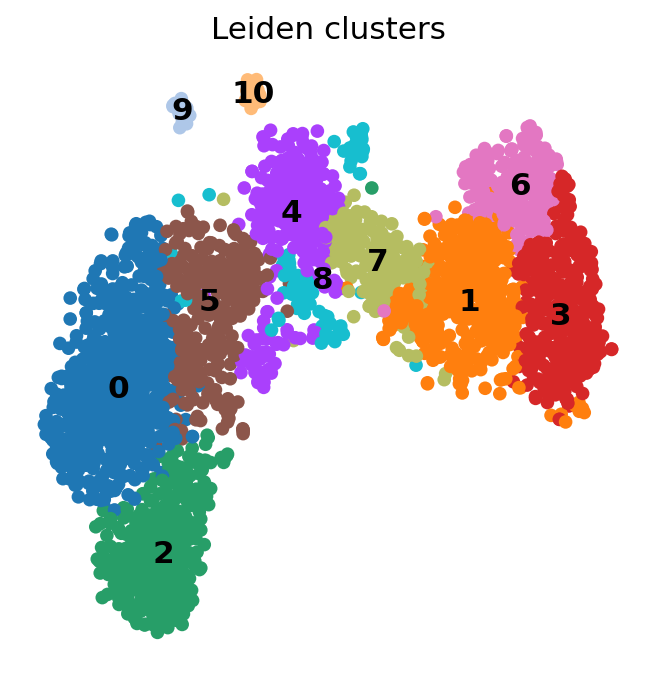

In [3]:
sc.pl.tsne(adata, color='leiden',legend_loc='on data',s=150, title='Leiden clusters')

## scRL's grid embedding and pseudotime alignment functions  
scRL 的网格嵌入和伪时间对齐功能 

 Getting the necessary information for the initialization of scRL.  
  获取初始化 scRL 的必要信息。

In [4]:
X = adata.obsm['X_tsne']

clusters = adata.obs['leiden']

clusters_colors = adata.uns['leiden_colors']

 Generating a grid embedding for the original t-SNE.  
 为原始 t-SNE 生成网格嵌入。

In [5]:
gres = scRL.grids_from_embedding(X)

Boundary generating:   4%|█▌                                   | 8/196 [00:00<00:04, 44.41it/s]/disk2/cai045/anaconda3/envs/scrl/lib/python3.9/site-packages/scRL/GridCore.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  B = arc_dist.groupby('G').apply(lambda x : x['D'].idxmax()).values
Boundary generating:   8%|██▉                                 | 16/196 [00:02<00:30,  5.96it/s]/disk2/cai045/anaconda3/envs/scrl/lib/python3.9/site-packages/scRL/GridCore.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude th

/disk2/cai045/anaconda3/envs/scrl/lib/python3.9/site-packages/scRL/GridCore.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  B = arc_dist.groupby('G').apply(lambda x : x['D'].idxmax()).values
/disk2/cai045/anaconda3/envs/scrl/lib/python3.9/site-packages/scRL/GridCore.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  B = arc_dist.groupby('G').apply(lambda x : x['D'].idxmax()).values
/disk2/cai045/anaconda3/envs

/disk2/cai045/anaconda3/envs/scrl/lib/python3.9/site-packages/scRL/GridCore.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  B = arc_dist.groupby('G').apply(lambda x : x['D'].idxmax()).values
/disk2/cai045/anaconda3/envs/scrl/lib/python3.9/site-packages/scRL/GridCore.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  B = arc_dist.groupby('G').apply(lambda x : x['D'].idxmax()).values
/disk2/cai045/anaconda3/envs

/disk2/cai045/anaconda3/envs/scrl/lib/python3.9/site-packages/scRL/GridCore.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  B = arc_dist.groupby('G').apply(lambda x : x['D'].idxmax()).values
/disk2/cai045/anaconda3/envs/scrl/lib/python3.9/site-packages/scRL/GridCore.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  B = arc_dist.groupby('G').apply(lambda x : x['D'].idxmax()).values
/disk2/cai045/anaconda3/envs

/disk2/cai045/anaconda3/envs/scrl/lib/python3.9/site-packages/scRL/GridCore.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  B = arc_dist.groupby('G').apply(lambda x : x['D'].idxmax()).values
/disk2/cai045/anaconda3/envs/scrl/lib/python3.9/site-packages/scRL/GridCore.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  B = arc_dist.groupby('G').apply(lambda x : x['D'].idxmax()).values
/disk2/cai045/anaconda3/envs

/disk2/cai045/anaconda3/envs/scrl/lib/python3.9/site-packages/scRL/GridCore.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  B = arc_dist.groupby('G').apply(lambda x : x['D'].idxmax()).values
/disk2/cai045/anaconda3/envs/scrl/lib/python3.9/site-packages/scRL/GridCore.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  B = arc_dist.groupby('G').apply(lambda x : x['D'].idxmax()).values
/disk2/cai045/anaconda3/envs

/disk2/cai045/anaconda3/envs/scrl/lib/python3.9/site-packages/scRL/GridCore.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  B = arc_dist.groupby('G').apply(lambda x : x['D'].idxmax()).values
/disk2/cai045/anaconda3/envs/scrl/lib/python3.9/site-packages/scRL/GridCore.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  B = arc_dist.groupby('G').apply(lambda x : x['D'].idxmax()).values
/disk2/cai045/anaconda3/envs

Time used for mapping grids: 8.08 seconds


 Projecting the annotation information onto the grid embedding space.  
  将注释信息投射到网格嵌入空间。

In [6]:
scRL.project_cluster(gres, clusters, clusters_colors)

Time used for projecting annotation : 1.00 seconds


 Select cluster 4 as starting points and aligning pseudotime.  
  选择第 4 组为起点，对齐伪时间。

In [7]:
scRL.align_pseudotime(gres, '4')

scRL.project_back(gres,'pseudotime')

Time used for aligning pseudo-time : 0.40 seconds


 Plotting the grids embedding.

In [8]:
g = gres.grids['grids'][gres.grids['mapped_grids']]

In [9]:
b = gres.grids['grids'][gres.grids['mapped_boundary']]

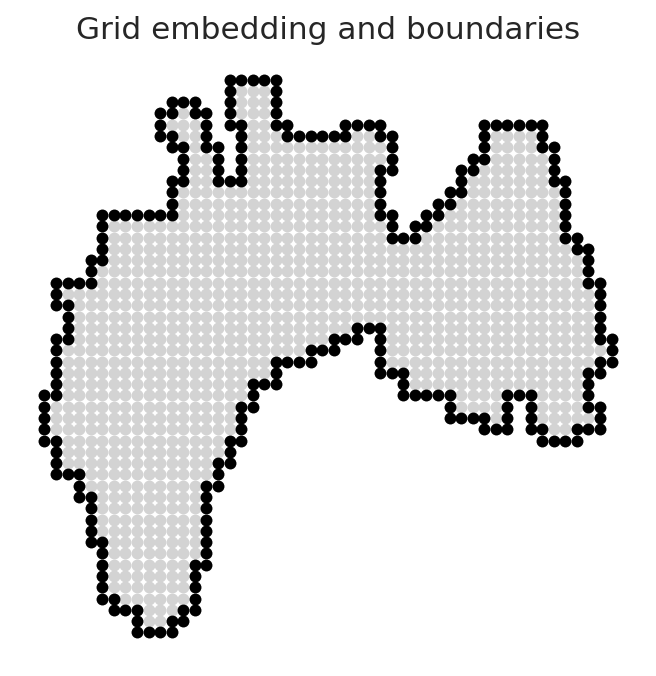

In [10]:
with sns.axes_style('white'):
    plt.scatter(g[:,0], g[:,1], marker='.',s=75,c='lightgrey')
    plt.scatter(b[:,0], b[:,1], marker='.',s=75,c='k')
    ax = plt.gca()
    ax.set_frame_on(False)
    ax.tick_params(labelleft=False, labelbottom=False)
    ax.set_title('Grid embedding and boundaries')

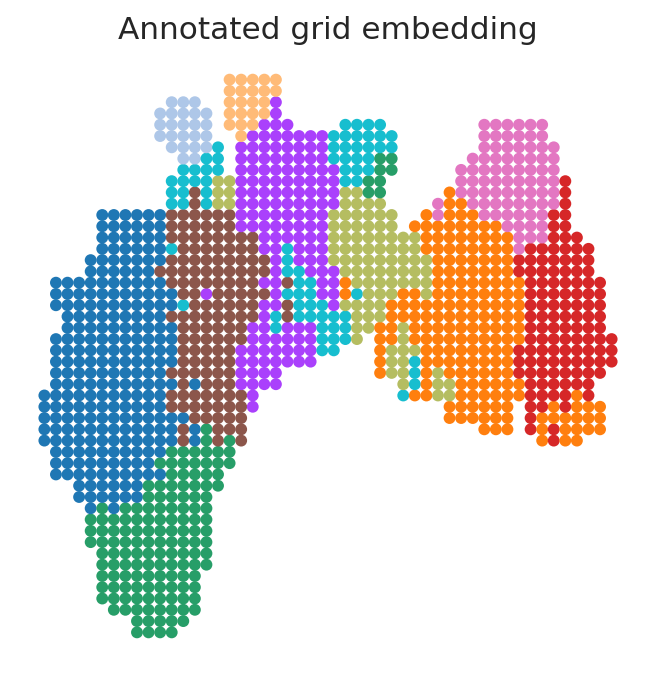

In [11]:
with sns.axes_style('white'):
    plt.scatter(g[:,0], g[:,1], marker='.',s=75,c=gres.grids['mapped_grids_colors'])
    ax = plt.gca()
    ax.set_frame_on(False)
    ax.tick_params(labelleft=False, labelbottom=False)
    ax.set_title('Annotated grid embedding')

In [12]:
adata.obs['scRL_time'] = gres.embedding['pseudotime']

**这里我的理解是：scRL_time只是它根据网格嵌入把之前算的拟时序值稍微对其或者说标准化了而已**

<Axes: title={'center': 'scRL_time'}, xlabel='tSNE1', ylabel='tSNE2'>

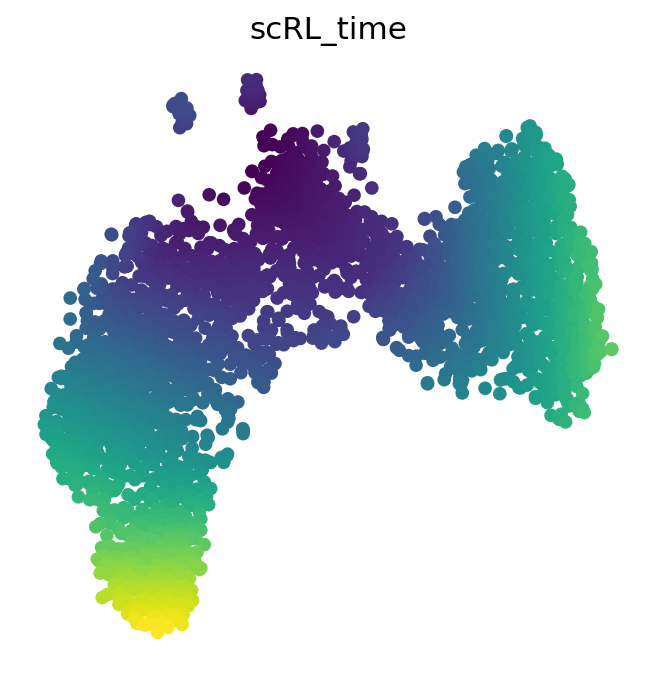

In [13]:
sc.pl.tsne(adata, color='scRL_time', frameon=False,s=150,cmap='viridis',colorbar_loc=None,legend_loc=None,show=False)


<Axes: title={'center': 'Mpo'}, xlabel='tSNE1', ylabel='tSNE2'>

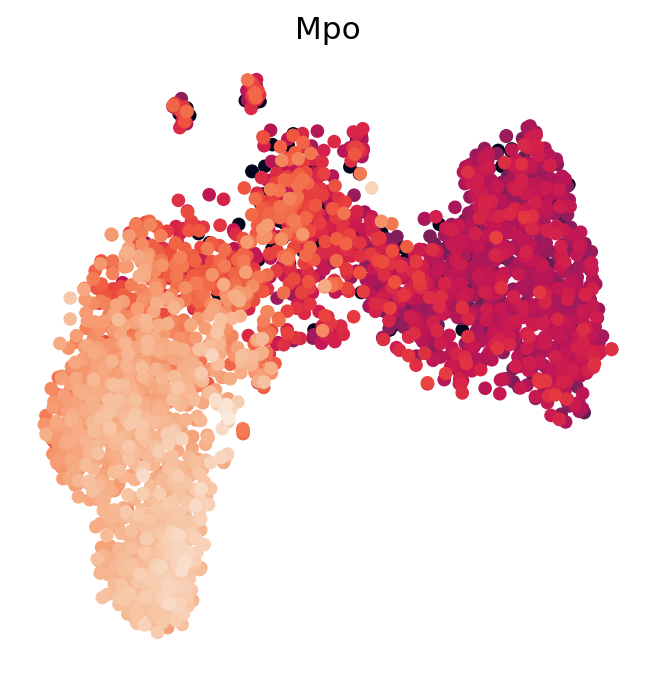

In [14]:
sc.pl.tsne(adata, color='Mpo', frameon=False,s=150,cmap='rocket',colorbar_loc=None,legend_loc=None,show=False)
##基因表达

In [15]:
exp = pd.DataFrame(adata[:,['Mpo','Klf1']].X,columns=['Mpo','Klf1'])

In [16]:
scRL.project(gres, exp)

In [17]:
gres.grids.keys()

dict_keys(['n', 'grids', 'masked_grids', 'mapped_grids', 'mapped_adj', 'mapped_boundary', 'mapped_travel', 'mapped_grids_clusters', 'mapped_grids_colors', 'pseudotime', 'proj'])

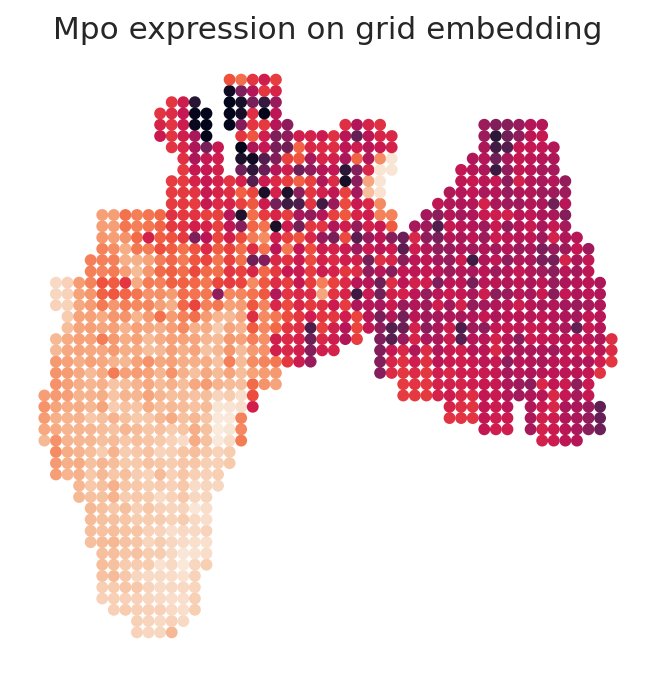

In [18]:
with sns.axes_style('white'):
    plt.scatter(g[:,0], g[:,1], marker='.',s=75, c=gres.grids['proj']['Mpo'])
    ax = plt.gca()
    ax.set_frame_on(False)
    ax.tick_params(labelleft=False, labelbottom=False)
    ax.set_title('Mpo expression on grid embedding')

## scRL's reward functions 

 Decision reward mode for lineage.  
 谱系决定奖励模式。

In [19]:
scRL.d_rewards(gres, starts='4', ends=['0','3','5'], mode='Decision')

Reward generating: 100%|█████████████████████████████████| 1277/1277 [00:00<00:00, 2324.90it/s]

Time used for generating rewards : 0.57 seconds


In [20]:
import matplotlib as mpl

 Reward generated  
  产生的奖励

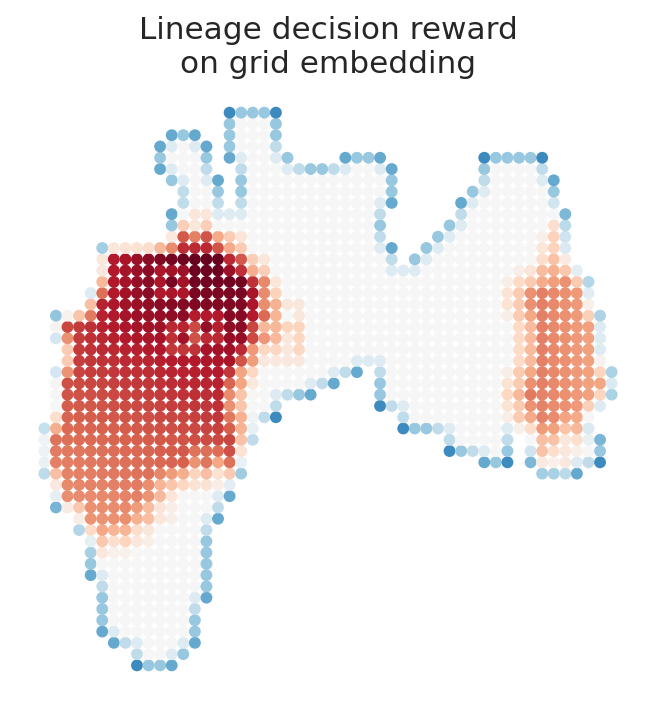

In [21]:
with sns.axes_style('white'):
    plt.scatter(g[:,0], g[:,1], marker='.',s=75, c=gres.qlearning['d_Decision_rewards'].sum(axis=1), cmap='RdBu_r', norm=mpl.colors.CenteredNorm())
    ax = plt.gca()
    ax.set_frame_on(False)
    ax.tick_params(labelleft=False, labelbottom=False)
    ax.set_title('Lineage decision reward\non grid embedding')

## Training functions 

 Fetching the PC space for constructing environment and feed the network  
 获取用于构建环境和馈送网络的 PC 空间

In [22]:
X_pca = adata.obsm['X_pca']

In [31]:
adata.obsm['X_pca']

array([[-12.95504   , -17.666908  ,   2.980597  , ...,  -0.20131682,
         -1.6973028 ,   1.5348927 ],
       [ -8.837339  ,  14.116394  ,  -2.1080194 , ...,  -0.6230951 ,
          2.3165772 ,  -0.08803141],
       [ 26.218033  ,  -0.46517465,   7.87105   , ...,   0.5211223 ,
         -0.3150218 ,   0.5128658 ],
       ...,
       [-13.265977  , -17.01108   ,   2.4594405 , ...,  -1.5340128 ,
         -2.9809253 ,  -0.90106094],
       [ -5.9481683 ,  16.055645  ,   4.319683  , ...,   0.4829793 ,
         -0.3312053 ,   3.740562  ],
       [ 24.97422   ,   1.5733644 ,   1.7212625 , ...,   0.5424541 ,
          0.236044  ,  -1.022776  ]], dtype=float32)

**注意，这里使用的是PCA降维数据，如果使用的是模型生成的细胞嵌入也不是不行哦**

In [23]:
t_mye = scRL.trainer('ActorCritic', gres, reward_type='d', starts_prob=False, X_latent=X_pca, num_episodes=5e3)

r_l, v_l = t_mye.train()

Iteration10: 100%|██████████████████████████| 500/500 [00:12<00:00, 40.02it/s, E=5000, R=22.18]


 Get the fate decision state value of myeloid lineage  
 获取髓系的命运决定状态值

In [24]:
scRL.get_state_value(gres, t_mye, 'Mye')

In [25]:
scRL.project_back(gres, 'Mye')

In [26]:
adata.obs['Mye'] = gres.embedding['Mye']

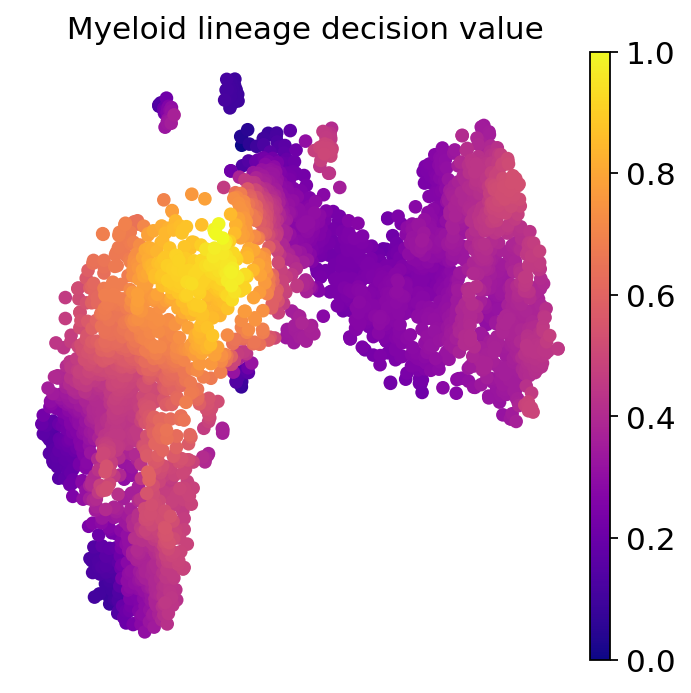

In [27]:
sc.pl.tsne(adata, color='Mye',s=150, cmap='plasma', title=' Myeloid lineage decision value')

 Get the trajectory

In [28]:
scRL.get_traj_df(gres, t_mye, key='Mye')

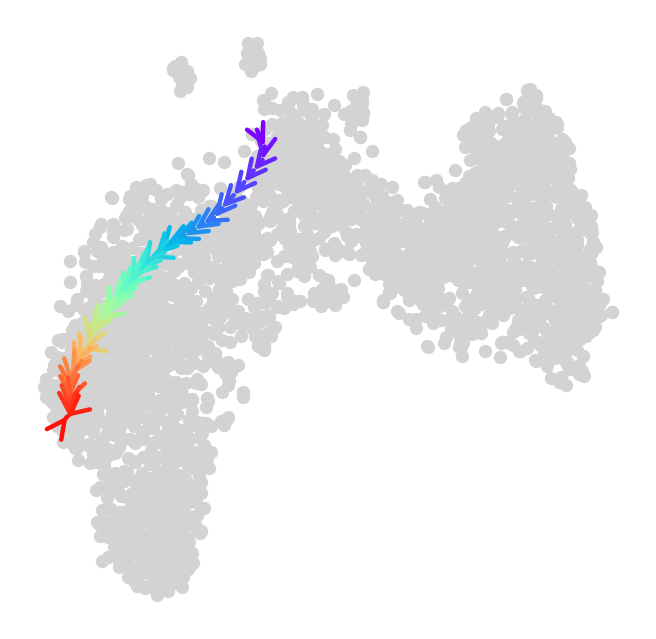

In [29]:
scRL.traj_results(gres, [], 'Mye')

In [30]:
adata.obs

,paul15_clusters,leiden,scRL_time,Mye
W31105,7MEP,4,0.040063,0.376977
W31106,15Mo,0,0.439804,0.405439
W31107,3Ery,3,0.692794,0.404097
W31108,15Mo,2,0.794946,0.127035
W31109,3Ery,3,0.679461,0.387683
...,...,...,...,...
W39164,2Ery,1,0.431158,0.342036
W39165,13Baso,0,0.440490,0.414024
W39166,7MEP,4,0.037382,0.128919
W39167,15Mo,2,0.789526,0.161800
